In [1]:
# Analisis del rendimiento por nivel de corrupcion
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone
from sklearn.metrics import recall_score

data_train = pd.concat([
    pd.read_csv("csv/train/clean.csv",     header=0, dtype={"video": str}),
    pd.read_csv("csv/train/corrupted.csv", header=0, dtype={"video": str}),
], ignore_index=True)
X_train_all = data_train.drop(columns=["video", "label"])
y_train_all = data_train["label"].astype(int).values

clean_test     = pd.read_csv("csv/test/clean.csv",     header=0, dtype={"video": str})
corrupted_test = pd.read_csv("csv/test/corrupted.csv", header=0, dtype={"video": str})

CORR_DIR = Path("../frames/test/corrupted")

def videos_de(level):
    return {"_".join(f.stem.split("_")[:-1]) for f in (CORR_DIR / level).glob("*.jpg")}

def test_set(level):
    corr = corrupted_test[corrupted_test["video"].isin(videos_de(level))]
    d = pd.concat([clean_test, corr], ignore_index=True)
    return d.drop(columns=["video", "label"]), d["label"].astype(int).values

In [2]:
# Subconjuntos acumulativos de cada parametro y seleccion de columnas
QUALS = [["80"], ["80", "85"], ["80", "85", "90"], ["80", "85", "90", "95"], ["80", "85", "90", "95", "100"]]
BASES = [["10"], ["10", "20"], ["10", "20", "40"], ["10", "20", "40", "60"]]
DIVS  = [["js"], ["js", "r"], ["js", "r", "t"]]

def regex(divs, bases, quals):
    return rf"^({'|'.join(divs)})_({'|'.join(bases)})_[1-9]_({'|'.join(quals)})$"

proto = RandomForestClassifier(n_estimators=100, n_jobs=-1)
cache = {}

def model(rgx):
    if rgx not in cache:
        cols = X_train_all.filter(regex=rgx).columns
        cache[rgx] = (clone(proto).fit(X_train_all[cols], y_train_all), cols)
    return cache[rgx]

def rec(rgx, X_test, y_test):
    # Recall sobre la clase corrupta, es decirm, la proporcion de fotogramas corruptos detectados
    m, cols = model(rgx)
    return recall_score(y_test, m.predict(X_test[cols]))

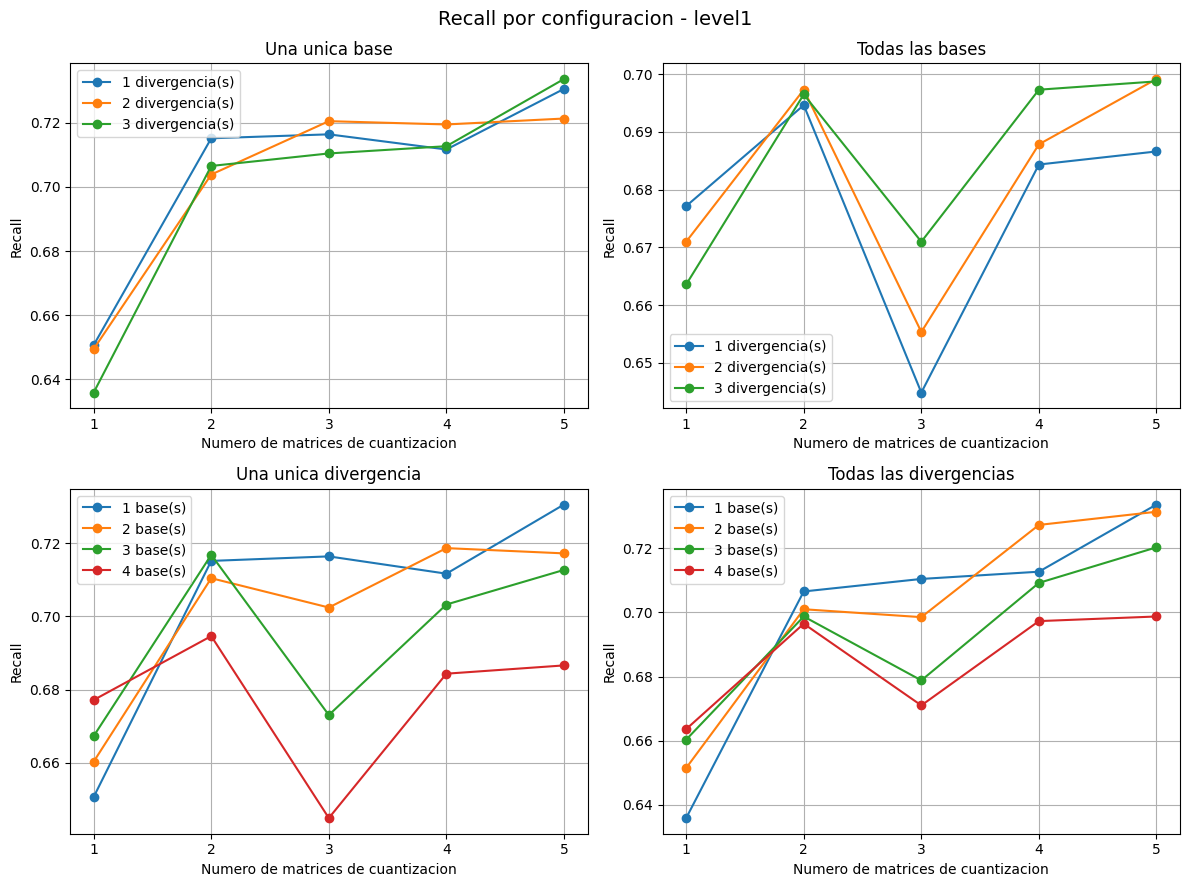

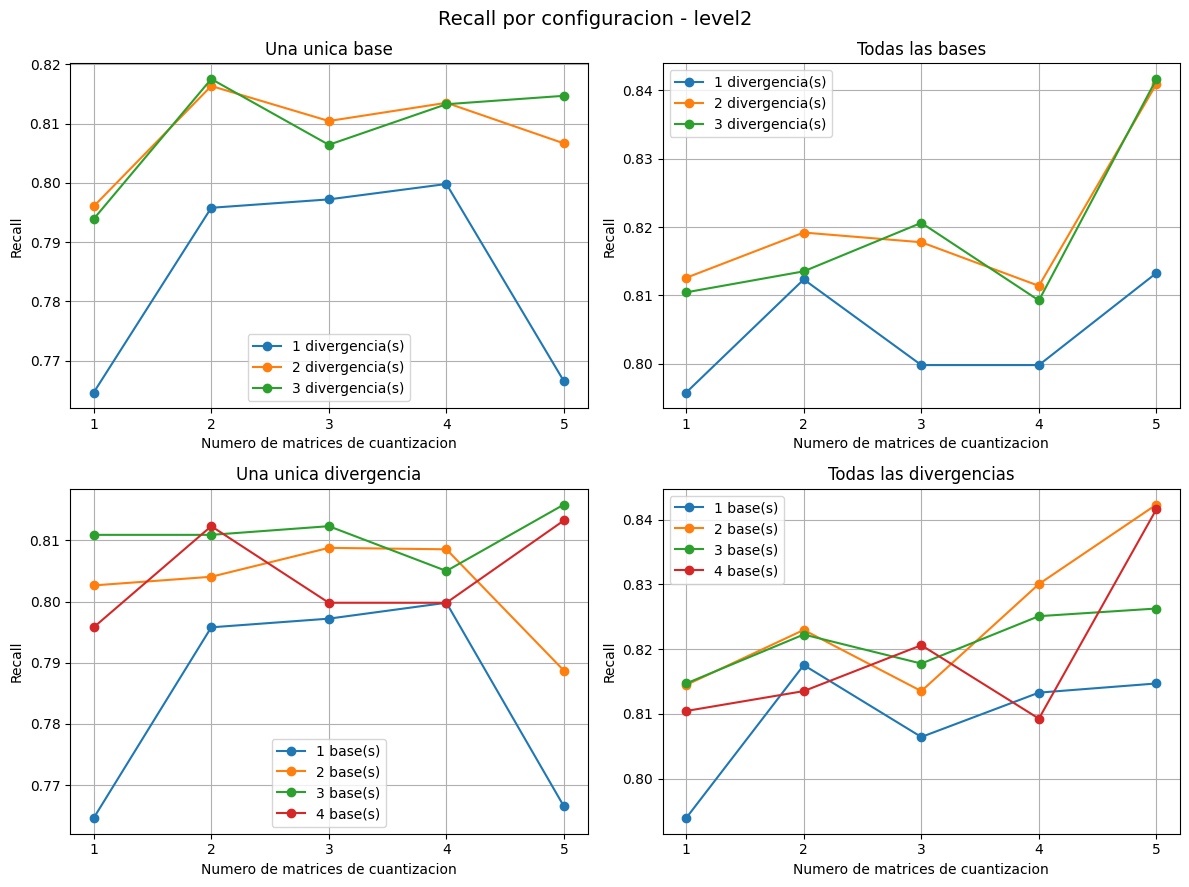

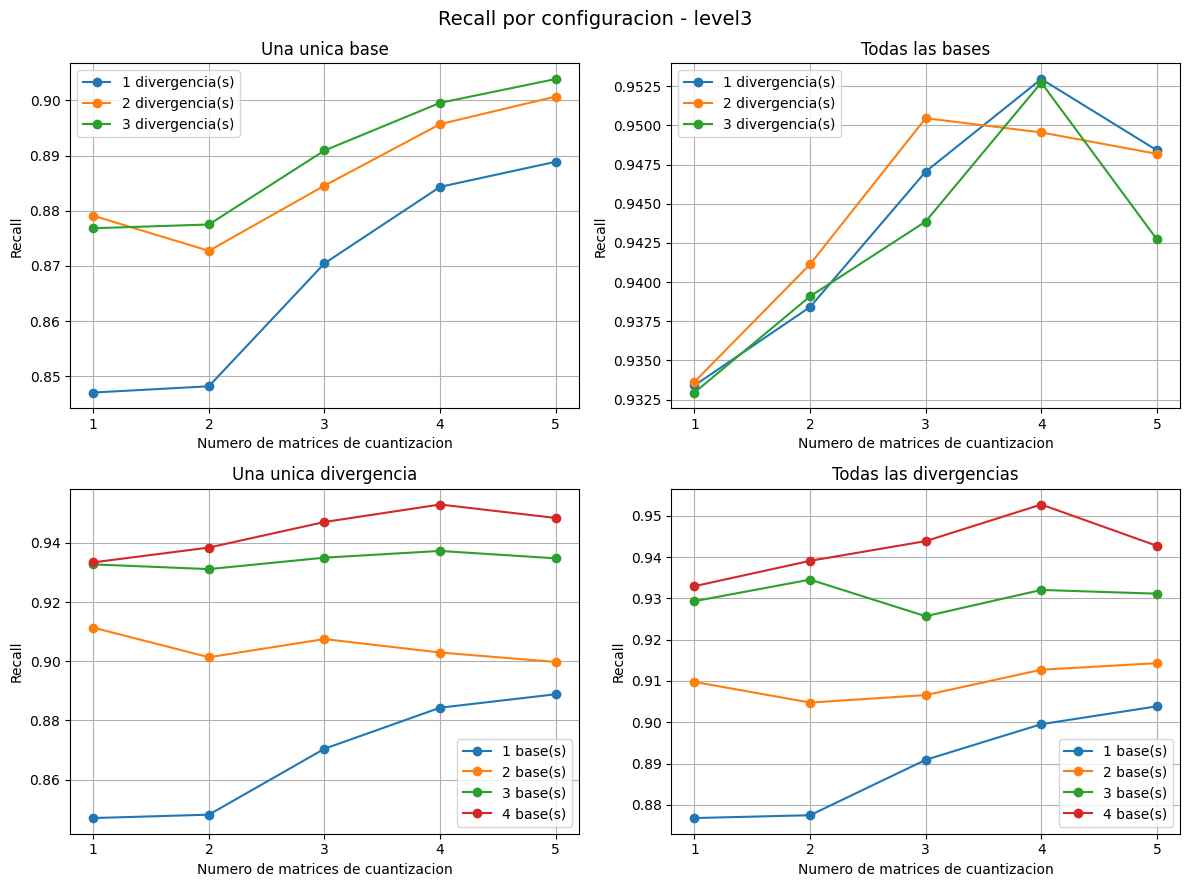

In [3]:
def figura_por_nivel(level):
    X_test, y_test = test_set(level)
    xs = [1, 2, 3, 4, 5]
    fig, axs = plt.subplots(2, 2, figsize=(12, 9))

    for divs in DIVS:
        ys = [rec(regex(divs, ["10"], q), X_test, y_test) for q in QUALS]
        axs[0, 0].plot(xs, ys, marker="o", label=f"{len(divs)} divergencia(s)")
    axs[0, 0].set_title("Una unica base")

    for divs in DIVS:
        ys = [rec(regex(divs, ["10", "20", "40", "60"], q), X_test, y_test) for q in QUALS]
        axs[0, 1].plot(xs, ys, marker="o", label=f"{len(divs)} divergencia(s)")
    axs[0, 1].set_title("Todas las bases")

    for bases in BASES:
        ys = [rec(regex(["js"], bases, q), X_test, y_test) for q in QUALS]
        axs[1, 0].plot(xs, ys, marker="o", label=f"{len(bases)} base(s)")
    axs[1, 0].set_title("Una unica divergencia")

    for bases in BASES:
        ys = [rec(regex(["js", "r", "t"], bases, q), X_test, y_test) for q in QUALS]
        axs[1, 1].plot(xs, ys, marker="o", label=f"{len(bases)} base(s)")
    axs[1, 1].set_title("Todas las divergencias")

    for ax in axs.flat:
        ax.set_xlabel("Numero de matrices de cuantizacion")
        ax.set_ylabel("Recall")
        ax.set_xticks(xs)
        ax.grid(True)
        ax.legend()
    fig.suptitle(f"Recall por configuracion - {level}", fontsize=14)
    plt.tight_layout()
    plt.savefig(f"recall_{level}.jpg", dpi=150)
    plt.show()

for level in ("level1", "level2", "level3"):
    figura_por_nivel(level)